# Alissa Beaderstadt Notebook - Exploratory Data Analysis of Restaurant Tipping Data

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

REQ: For EDA projects, include dataset, description, and source information.

- Author: [Alissa Beaderstadt](https://github.com/abeaderstadt/)
- Repository: [datafun-04-notebooks](https://github.com/abeaderstadt/datafun-04-notebooks/)
- Purpose: Demonstrate a repeatable EDA workflow for a new, unexplored dataset
- Date: 2026-05

## Dataset Information

- Dataset: Tips
- Description: Restaurant tipping data that includes total bill amount, tip amount, customer sex, smoker status, day of the week, time of day, and party size.
- Source: Seaborn built-in dataset
- Original Collection: Data from a restaurant server's tip records, commonly used for statistical analysis and data visualization examples.
- Citation: Seaborn Tips Dataset
- Access: Available via Seaborn's built-in datasets using `sns.load_dataset("tips")`


## Section 1. Project Setup and Imports

All imports and configuration appear once, at the top of the notebook.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes it clear what must be installed



In [1]:
# This is a Python cell.

# Imports at the top of the file
# REQ.EXTERNAL.DEPS: External packages must be defined in pyproject.toml
# REQ.EXTERNAL.DEPS.INSTALLED: external packages must be installed in the environment using uv sync command
# REQ.EXTERNAL.DEPS.IMPORTED: external packages used in this notebook must be imported here


from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Type hint for Axes object (basic plot type returned by Seaborn)
# A seaborn plot is a set of axes and you can set the title, labels, etc. on the axes.

# A figure can contain multiple axes (plots)
# from matplotlib.figure import Figure

# Pandas display configuration (helps in notebooks)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Imports complete.")

Imports complete.


## Section 2. Load the Data


WHY: Before analysis, load the data to confirm:

- The dataset loads successfully
- The structure matches expectations
- Column names are available and readable



In [2]:
# Python cell

# Load the tips dataset from Seaborn
# Into a pandas DataFrame (2D table)
tips_df: pd.DataFrame = sns.load_dataset("tips")

# Preview the first few rows
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


**Observations:**<br>
The tips dataset includes restaurant bill and tip information along with context like sex, smoker status, day, time, and party size. It contains both numeric columns (like total_bill and tip) and categorical columns (like day and time).


## Section 3. Inspect Data Shape and Structure

WHY: First, understand the shape (basic structure) of the data:

- How many rows and columns are there?
- What types of data are present?
- Are there obvious missing values?

This step determines challenges we might have downstream (later).


In [3]:
# Section 3 Python cell

# Get shape - number of rows and columns
shape: tuple[int, int] = tips_df.shape

# Communicate the shape clearly
print(f"The tips dataset has {shape[0]} rows and {shape[1]} columns.")

The tips dataset has 244 rows and 7 columns.


In [4]:
# Section 3 Python cell

# Display column names and data types
tips_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [5]:
# Section 3 Python cell

# List the column names
print("Column names:")
print(list(tips_df.columns))

Column names:
['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


**Observations:**<br>
The dataset has 244 rows and 7 columns, and there are no missing values. It includes a mix of numeric columns like total_bill, tip, and size, along with categorical columns like sex, smoker, day, and time.

The structure looks clean and organized, and the column names are already pretty clear, so no extra cleanup is needed here before moving on.

## Section 4. Create Data Dictionary and Check Data Quality

WHY: Missing data is normal. We need to find out how much and where.

Missing data affects:

- Visualizations
- Summary statistics
- Machine learning models

LOOK FOR: 

- Columns with many missing values
- Patterns (entire rows missing multiple fields)



In [6]:
# Section 4 Python cell

# Count missing values in each column
print("Missing values per column:")
print(tips_df.isnull().sum())

Missing values per column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [7]:
# Section 4 Python cell

# Check for duplicate rows
num_duplicates = tips_df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 1


**Observations:**<br>
There are no missing values in any of the columns, and the dataset is already complete across all 244 rows.
Next, I will remove the single duplicate row to keep the dataset clean, since it does not add new information.

## Section 5. Create Clean View for EDA

WHY: We often want to work with complete data for visualizations and statistics.

Strategy:
- Keep the original DataFrame unchanged
- Create a separate clean view by dropping rows with missing values


In [8]:
# Section 5 Python cell

# Clean dataset (remove duplicates only, since no missing values exist)
tips_clean = tips_df.drop_duplicates()

# Compare sizes
print(f"Original dataset: {len(tips_df)} rows")
print(f"Clean dataset: {len(tips_clean)} rows")
print(f"Rows removed: {len(tips_df) - len(tips_clean)}")

Original dataset: 244 rows
Clean dataset: 243 rows
Rows removed: 1


**Observations:**<br>
The dataset had no missing values, and removing duplicates reduced it by 1 row, so the data is already very clean.

## Section 5b. Creating Derived Features

In [9]:
# Derived feature: spending category
def add_spending_category(df: pd.DataFrame) -> pd.DataFrame:
    """Add spending categories based on total bill amount."""

    df = df.copy()

    df["spending_category"] = pd.cut(
        df["total_bill"],
        bins=[0, 15, 30, 60],
        labels=["Low", "Medium", "High"],
    )

    return df

In [10]:
# Derived feature: bill_vs_day_avg
def add_bill_vs_day_avg(df: pd.DataFrame) -> pd.DataFrame:
    """Compare each bill to the average bill for that day."""

    df = df.copy()

    day_avg = df.groupby("day")["total_bill"].transform("mean")

    df["bill_vs_day_avg"] = df["total_bill"] / day_avg

    return df

In [11]:
# Apply new feartures to the clean dataset
tips_clean = add_spending_category(tips_clean)
tips_clean = add_bill_vs_day_avg(tips_clean)

tips_clean.groupby("day").sample(3, random_state=42)

,total_bill,tip,sex,smoker,day,time,size,spending_category,bill_vs_day_avg
77,27.20,4.00,Male,No,Thur,Lunch,4,Medium,1.531574
82,10.07,1.83,Female,No,Thur,Lunch,1,Low,0.567020
191,19.81,4.19,Female,Yes,Thur,Lunch,2,Medium,1.115459
223,15.98,3.00,Female,No,Fri,Lunch,3,Medium,0.931693
220,12.16,2.20,Male,Yes,Fri,Lunch,2,Low,0.708973
94,22.75,3.25,Female,No,Fri,Dinner,2,Medium,1.326408
105,15.36,1.64,Male,Yes,Sat,Dinner,2,Medium,0.751417
218,7.74,1.44,Male,Yes,Sat,Dinner,2,Low,0.378644
65,20.08,3.15,Male,No,Sat,Dinner,3,Medium,0.982321
12,15.42,1.57,Male,No,Sun,Dinner,2,Medium,0.720224


**Observations:**<br>
The spending_category column groups customers into Low, Medium, and High based on their total bill, which makes it easier to compare overall spending behavior without focusing on exact values.

The bill_vs_day_avg feature was especially useful because it shows how each bill compares to the average for that day. Values above 1 indicate above-average spending for that day, while values below 1 indicate below-average spending.

## Section 6. Descriptive Statistics for Numeric Columns

WHY: Summary statistics give us a quick overview of the numeric data:

- Central tendency (mean)
- Spread (std, min, max)
- Distribution shape (quartiles)

In [12]:
# Section 6 Python cell

# Summary statistics for numeric columns
tips_clean.describe()

,total_bill,tip,size,bill_vs_day_avg
count,243.000000,243.000000,243.000000,243.000000
mean,19.813868,3.002387,2.572016,1.000000
std,8.910071,1.385002,0.952356,0.442742
min,3.070000,1.000000,1.000000,0.150186
25%,13.380000,2.000000,2.000000,0.696287
50%,17.810000,2.920000,2.000000,0.899800
75%,24.175000,3.575000,3.000000,1.192655
max,50.810000,10.000000,6.000000,2.485644


**Observations:**<br>
Tip amounts average around $3, but range from $1 to $10, which suggests some customers tip much more generously than others. Party sizes are mostly small, averaging around 2-3 people.

The bill_vs_day_avg feature centers around 1, which makes sense since it represents how each bill compares to the daily average. Values above and below 1 show clear variation in spending behavior depending on the table.

In [13]:
# Section 6 Python cell

# Calculate statistics for total bill with numpy
mean_total_bill = np.mean(tips_clean["total_bill"])
std_total_bill = np.std(tips_clean["total_bill"])
min_total_bill = np.min(tips_clean["total_bill"])
max_total_bill = np.max(tips_clean["total_bill"])
range_total_bill = np.ptp(tips_clean["total_bill"])  # peak to peak (max - min)

print("Total Bill Statistics (using numpy):")
print(f"  Mean: ${mean_total_bill:.2f}")
print(f"  Std Dev: ${std_total_bill:.2f}")
print(f"  Min: ${min_total_bill:.2f}")
print(f"  Max: ${max_total_bill:.2f}")
print(f"  Range: ${range_total_bill:.2f}")

Total Bill Statistics (using numpy):
  Mean: $19.81
  Std Dev: $8.89
  Min: $3.07
  Max: $50.81
  Range: $47.74


**Observations:**<br>
The summary statistics show that the average total bill is about $19.79, with a fairly wide spread (from $3.07 up to $50.81). The standard deviation also shows there is a good amount of variation in spending across customers.

## Section 7. Correlation Matrix for Numeric Columns

WHY: Correlation tells us how numeric variables relate to each other.

- Values near 1 or -1 indicate strong relationships
- Values near 0 indicate weak or no linear relationship


In [14]:
# Section 7 Python cell

# Select only numeric columns and compute correlation
numeric_cols = tips_clean.select_dtypes(include="number")
correlation_matrix = numeric_cols.corr()
print(correlation_matrix)

                 total_bill       tip      size  bill_vs_day_avg
total_bill         1.000000  0.674998  0.597589         0.980556
tip                0.674998  1.000000  0.488400         0.666384
size               0.597589  0.488400  1.000000         0.578922
bill_vs_day_avg    0.980556  0.666384  0.578922         1.000000


**Observations:**<br>
The strongest correlation is between total_bill and bill_vs_day_avg, which is expected since the feature is derived from total bill. There are also moderate positive relationships between bill size, tip amount, and party size, showing that larger groups tend to spend and tip more.

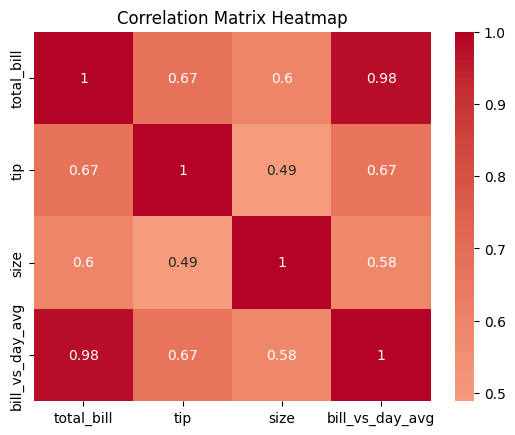

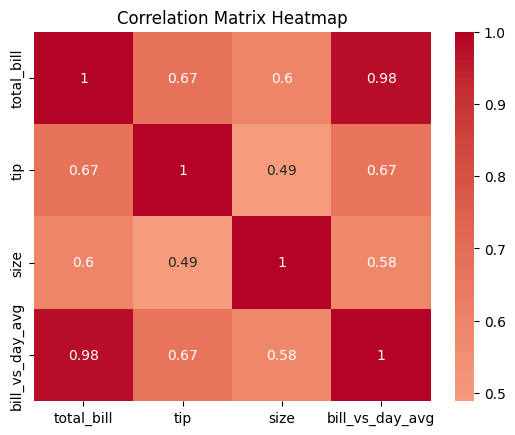

In [15]:
# Section 7 Python cell

# Visualize the correlation matrix as a heatmap
# Set annotations to True to show correlation values
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()


# Visualize the correlation matrix as a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix Heatmap")
plt.show()

Interpretation:

 - Values close to 1 (dark red) = strong positive correlation (both increase together)
 - Values close to -1 (dark blue) = strong negative correlation (one increases, other decreases)
 - Values close to 0 (white) = little or no linear relationship
 - The diagonal is always 1 (each variable correlates perfectly with itself)

From this heatmap, we can see that total_bill and bill_vs_day_avg have a very strong positive correlation (about 0.98). This is expected since bill_vs_day_avg is derived from total_bill.


## Section 8. Make Plots

WHY: Visualizations reveal patterns not obvious in tables.

Create:
1. A scatter plot to see relationships between two variables
2. A box plot to compare distributions across groups


Text(0.5, 1.0, 'Chart 1. Total Bill vs. Tip (by Day)')

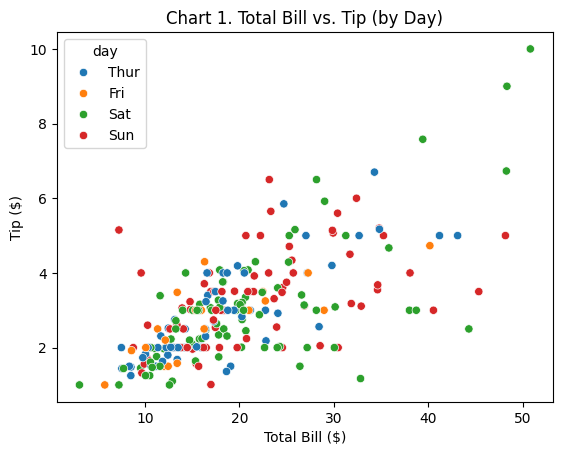

In [16]:
# Section 8 Python cell - use "Run All" so prior cells are executed first.

# Create a scatter plot of total bill vs. tip, colored by day of the week
# We need to know our dataset column names so we can use them to set x, y, and hue (color)
scatter_plt: Axes = sns.scatterplot(data=tips_clean, x="total_bill", y="tip", hue="day")

# Set axis labels using the Matplotlib Axes methods set_xlabel() and set_ylabel()
scatter_plt.set_xlabel("Total Bill ($)")
scatter_plt.set_ylabel("Tip ($)")

# Set the title using the Matplotlib Axes set_title() method
scatter_plt.set_title("Chart 1. Total Bill vs. Tip (by Day)")

# Run by clicking Run All in the Menu up top

**Observations:**<br>
The scatter plot shows a clear positive relationship between total bill and tip. While the data is colored by day, there is no strong separation between days, although a few higher and lower values appear on Saturday and Friday.

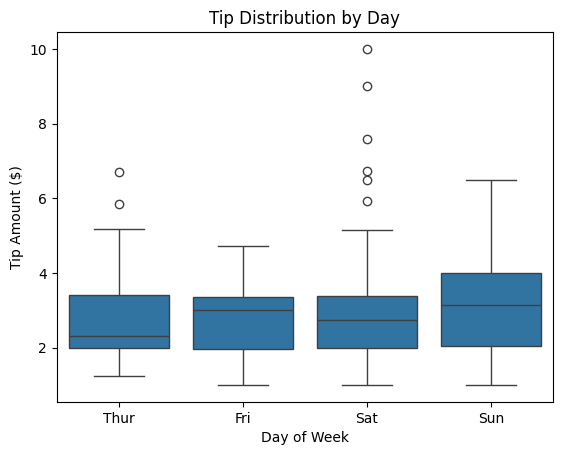

In [17]:
# Create a box plot of tip amount by day
box_plt = sns.boxplot(data=tips_clean, x="day", y="tip")

box_plt.set_xlabel("Day of Week")
box_plt.set_ylabel("Tip Amount ($)")
box_plt.set_title("Tip Distribution by Day")

plt.show()

**Observations:**<br>
The box plot shows how tip amounts vary across different days. The median tip values are fairly consistent, with some variation in spread and a few higher outliers on Thursdays and Saturdays. Overall, there are no dramatic differences between days, which suggests that tipping behavior is pretty stable throughout the week.

## Section 9. Conclusion
Overall, the analysis shows a consistent relationship between total bill and tip amount, with larger groups generally spending and tipping more. The derived features helped highlight relative spending patterns and made comparisons across the dataset easier to interpret. No strong differences were observed across days, suggesting customer behavior is fairly consistent over time.